# Personal Information
Name: **Maja Kubara**

StudentID: **14498863**

Email: [**maja.kubara@student.uva.nl**](youremail@student.uva.nl)

github: https://github.com/Majacodre/Extreme-precipitation

Submitted on: **22.03.2026**


# Content
The KNMI dataset was retrieved from (..) and includes hourly datapoints for metoerological variables between 1970 and 2024. The luchtmeetnet data was downladed from (...), it containes readings from air quality stations such as particulate matter. The datapoints have an hourly interval and include data between 1976 and 2023.

Prior to EDA the datasets were merged via distance and date variables. The distance was calculated based on coordinates available in datasets via cKDTree algorithm. After merging both datasets, the final dataset includes data from 1970 until 2024 (the full time interval from KNMI) with daily readings. Therefore, the percentage of missing air quality data points is higher than the ones from KNMI dataset.

# Data Description

It can be seen that the air quality data has a high percentage of missing points, it could be due to the way merging was performed. Since the merging was done based on nearest station and time, if the nearest station has no available data, it would show up as missing. This can be observed in the map with stations, some KNMI stations have no link to any Lucht station due to time mismatch. 

Furthermore, the class imbalance can be observed, the light to moderate rain has the highest amount of readings while heavy and extreme precipiatation have only few. The heatmaps are indicators of where the highest precipitation levels appear in the Netherlands. It can be observed that some of the regions with the highest precipitation belong to the stations with no link to any Lucht station, it is important not to drop/remove those readings for machine learning as there are only a few point belonging to heavy or extreme precipitation class. Instead, the data can be interpolated with the mean of all the station at a given time. 

Lastly, the correaltion plots show somewhat high correlation between precipitation (RH) and other variables. The spearman correlation achieves higher scores than pearson correlation, suggesting that the relationship is not linear. Based on the boxplots, it can be seen that the moderate/light precipitation has more deviation in all the variables than other classes, however, it could be due to a low number of data points in the remaining 2 classes. 

In [1]:
# Imports
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [46]:
data = pd.read_parquet("data/full_dataset.parquet")
knmi = pd.read_parquet("data/KNMI_final_data.parquet")
lucht = pd.read_parquet("data/Luchtmeetnet_final_data.parquet")

# Categorise precipitation
# https://www.knmi.nl/kennis-en-datacentrum/uitleg/extreme-neerslag
data["precipitation_category"] = pd.cut(data["RH"], bins=[-np.inf, 50, 100, np.inf], labels=["Light-Moderate", "Heavy", "Extreme"])

### Analysis 1: Dataset description 


In [3]:
summary_stats = pd.DataFrame({
    "data count": data.count(),
    "missing values": data.isnull().sum(),
    "percentage missing": (data.isnull().sum() / len(data)) * 100})

In [4]:
summary_stats

,data count,missing values,percentage missing
time,711006,0,0.000000
RH,711006,0,0.000000
DR,711006,0,0.000000
SQ,711006,0,0.000000
Q,711006,0,0.000000
temp,535079,175927,24.743392
TD,523821,187185,26.326782
FF,695367,15639,2.199559
FH,683752,27254,3.833160
P,413196,297810,41.885722


In [5]:
# Precipitation category counts
category_counts = data["precipitation_category"].value_counts()
print(category_counts)


precipitation_category
Light-Moderate    710872
Heavy                128
Extreme                6
Name: count, dtype: int64


In [47]:
lucht["time"].max(), lucht["time"].min()

(Timestamp('2023-12-31 00:00:00'), Timestamp('1976-01-03 00:00:00'))

In [48]:
knmi["time"].max(), knmi["time"].min()

(Timestamp('2024-11-18 00:00:00'), Timestamp('1970-01-01 00:00:00'))

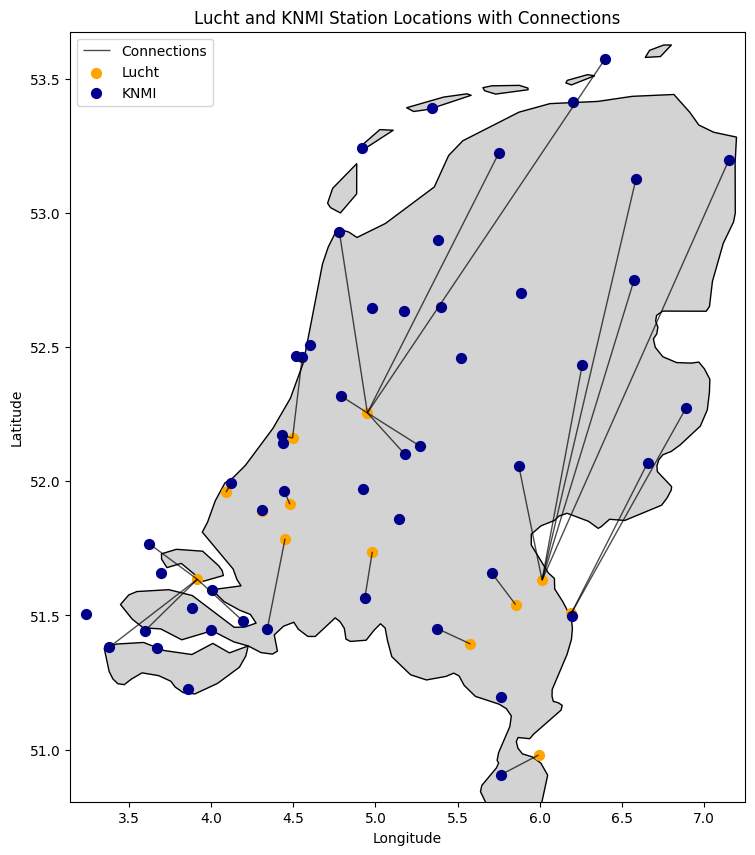

In [14]:
world = gpd.read_file(
    "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
)

netherlands = world[world["NAME"] == "Netherlands"]

pairs = data[["longitude_lucht", "latitude_lucht", "longitude_knmi", "latitude_knmi"]].drop_duplicates().dropna()
lucht_df = data[["longitude_lucht", "latitude_lucht"]].drop_duplicates().dropna()
knmi_df = data[["longitude_knmi", "latitude_knmi"]].drop_duplicates().dropna()

lucht_gdf = gpd.GeoDataFrame(
    lucht_df, 
    geometry=gpd.points_from_xy(lucht_df.longitude_lucht, lucht_df.latitude_lucht),
    crs="EPSG:4326"
)

knmi_gdf = gpd.GeoDataFrame(
    knmi_df, 
    geometry=gpd.points_from_xy(knmi_df.longitude_knmi, knmi_df.latitude_knmi),
    crs="EPSG:4326"
)

pairs["geometry"] = pairs.apply(
    lambda row: LineString([
        (row.longitude_lucht, row.latitude_lucht),
        (row.longitude_knmi, row.latitude_knmi)
    ]),
    axis=1
)

lines_gdf = gpd.GeoDataFrame(pairs, geometry="geometry", crs="EPSG:4326")

# Plotting

fig, ax = plt.subplots(figsize=(10,10))

# Netherlands map
netherlands.plot(ax=ax, color='lightgray', edgecolor='black')

# Lines between stations
lines_gdf.plot(ax=ax, color='black', linewidth=1, alpha=0.7, label='Connections')

# Plot stations
lucht_gdf.plot(ax=ax, color='orange', markersize=50, label='Lucht')
knmi_gdf.plot(ax=ax, color='darkblue', markersize=50, label='KNMI')

# Set plot limits to focus on points (tight zoom)
all_lons = pd.concat([lucht_df["longitude_lucht"], knmi_df["longitude_knmi"]])
all_lats = pd.concat([lucht_df["latitude_lucht"], knmi_df["latitude_knmi"]])
buffer = 0.1  # extra space around points
ax.set_xlim(all_lons.min() - buffer, all_lons.max() + buffer)
ax.set_ylim(all_lats.min() - buffer, all_lats.max() + buffer)

plt.legend()
plt.title("Lucht and KNMI Station Locations with Connections")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Analysis 2: dataset description after excluding KNMI with no Lucht pairs

In [7]:
data2 = data.dropna(subset=["latitude_lucht", "longitude_lucht"])

In [8]:
summary_stats = pd.DataFrame({
    "data count": data2.count(),
    "missing values": data2.isnull().sum(),
    "percentage missing": (data2.isnull().sum() / len(data2)) * 100})

In [9]:
summary_stats

,data count,missing values,percentage missing
time,23522,0,0.000000
RH,23522,0,0.000000
DR,23522,0,0.000000
SQ,23522,0,0.000000
Q,23522,0,0.000000
temp,21639,1883,8.005272
TD,20733,2789,11.856985
FF,23502,20,0.085027
FH,23501,21,0.089278
P,19097,4425,18.812176


In [10]:
# Precipitation category counts
category_counts = data2["precipitation_category"].value_counts()
print(category_counts)

precipitation_category
Light-Moderate    23521
Heavy                 1
Extreme               0
Name: count, dtype: int64


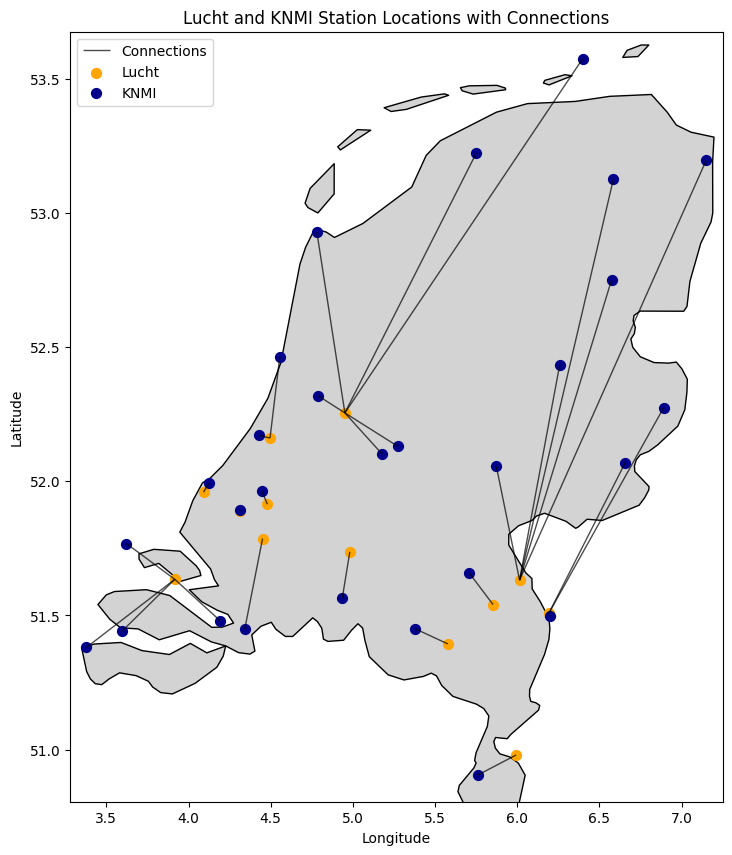

In [ ]:
world = gpd.read_file(
    "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
)

netherlands = world[world["NAME"] == "Netherlands"]

pairs = data2[["longitude_lucht", "latitude_lucht", "longitude_knmi", "latitude_knmi"]].drop_duplicates().dropna()
lucht_df = data2[["longitude_lucht", "latitude_lucht"]].drop_duplicates().dropna()
knmi_df = data2[["longitude_knmi", "latitude_knmi"]].drop_duplicates().dropna()

lucht_gdf = gpd.GeoDataFrame(
    lucht_df, 
    geometry=gpd.points_from_xy(lucht_df.longitude_lucht, lucht_df.latitude_lucht),
    crs="EPSG:4326"
)

knmi_gdf = gpd.GeoDataFrame(
    knmi_df, 
    geometry=gpd.points_from_xy(knmi_df.longitude_knmi, knmi_df.latitude_knmi),
    crs="EPSG:4326"
)

pairs["geometry"] = pairs.apply(
    lambda row: LineString([
        (row.longitude_lucht, row.latitude_lucht),
        (row.longitude_knmi, row.latitude_knmi)
    ]),
    axis=1
)

lines_gdf = gpd.GeoDataFrame(pairs, geometry="geometry", crs="EPSG:4326")

# Plotting

fig, ax = plt.subplots(figsize=(10,10))

netherlands.plot(ax=ax, color='lightgray', edgecolor='black')
lines_gdf.plot(ax=ax, color='black', linewidth=1, alpha=0.7, label='Connections')
lucht_gdf.plot(ax=ax, color='orange', markersize=50, label='Lucht')
knmi_gdf.plot(ax=ax, color='darkblue', markersize=50, label='KNMI')

# Set plot boundries
all_lons = pd.concat([lucht_df["longitude_lucht"], knmi_df["longitude_knmi"]])
all_lats = pd.concat([lucht_df["latitude_lucht"], knmi_df["latitude_knmi"]])
buffer = 0.1  
ax.set_xlim(all_lons.min() - buffer, all_lons.max() + buffer)
ax.set_ylim(all_lats.min() - buffer, all_lats.max() + buffer)

plt.legend()
plt.title("Lucht and KNMI Station Locations with Connections")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Analysis 3: Heatmaps with the full dataset

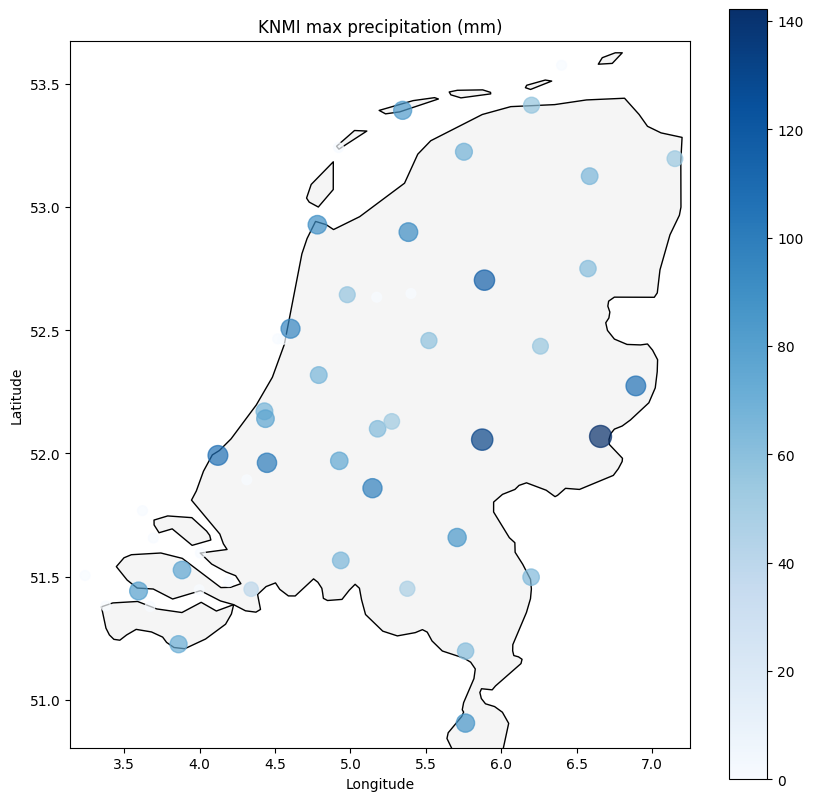

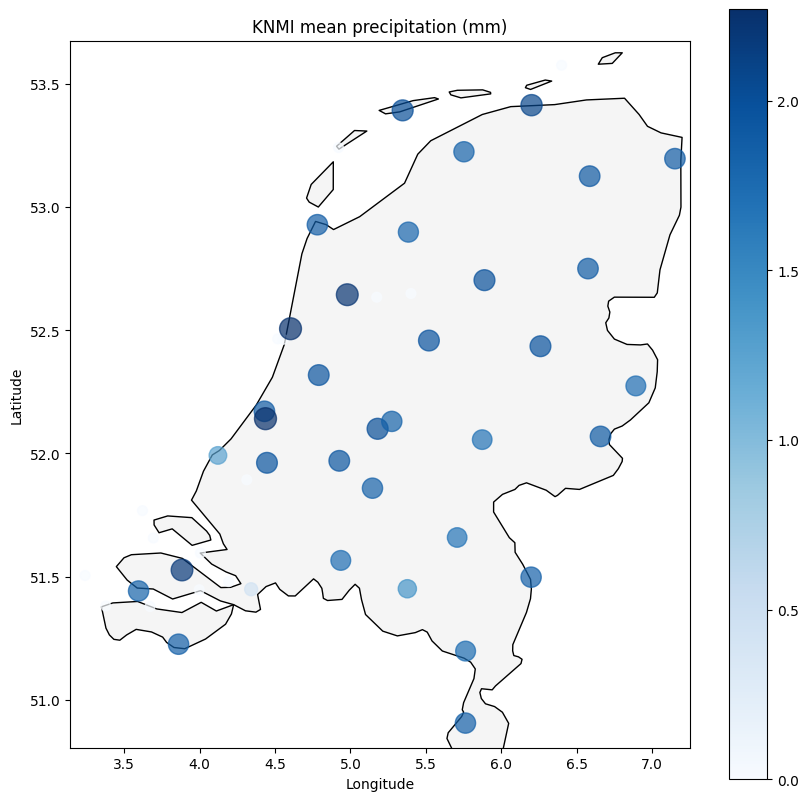

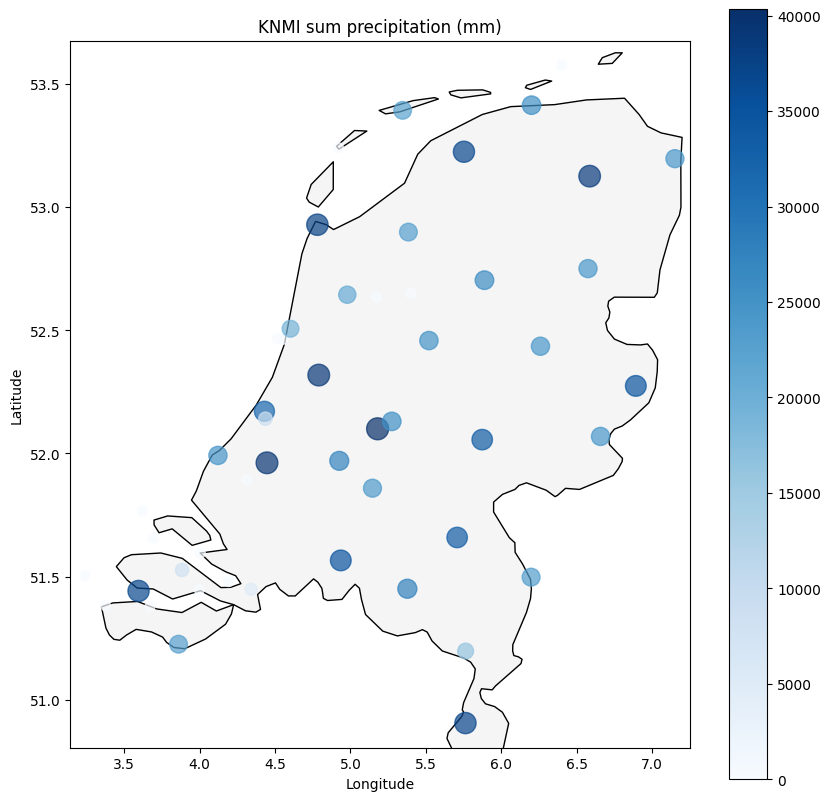

In [21]:
knmi_precip_df = data[['longitude_knmi', 'latitude_knmi', 'RH']].dropna()

# Aggregate by station for max, mean, sum 
agg_df = knmi_precip_df.groupby(['longitude_knmi', 'latitude_knmi']).RH.agg(['max', 'mean', 'sum']).reset_index()

knmi_gdf = gpd.GeoDataFrame(
    agg_df,
    geometry=gpd.points_from_xy(agg_df.longitude_knmi, agg_df.latitude_knmi),
    crs="EPSG:4326"
)

# Function to plot heatmap
def plot_heatmap(gdf, column, title, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(10,10))
    netherlands.plot(ax=ax, color='whitesmoke', edgecolor='black')
    
    # Use markersize proportional to value
    sizes = (gdf[column] - gdf[column].min()) / (gdf[column].max() - gdf[column].min()) * 200 + 50
    
    gdf.plot(
        ax=ax,
        column=column,
        cmap=cmap,
        markersize=sizes,
        legend=True,
        alpha=0.7
    )
    
    # Set plot boundries
    all_lons = pd.concat([lucht_df["longitude_lucht"], knmi_df["longitude_knmi"]])
    all_lats = pd.concat([lucht_df["latitude_lucht"], knmi_df["latitude_knmi"]])
    buffer = 0.1 
    ax.set_xlim(all_lons.min() - buffer, all_lons.max() + buffer)
    ax.set_ylim(all_lats.min() - buffer, all_lats.max() + buffer)

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

# Plot max, mean, and sum heatmaps
plot_heatmap(knmi_gdf, 'max', 'KNMI max precipitation (mm)')
plot_heatmap(knmi_gdf, 'mean', 'KNMI mean precipitation (mm)')
plot_heatmap(knmi_gdf, 'sum', 'KNMI sum precipitation (mm)')

### Analysis 4: Correlation

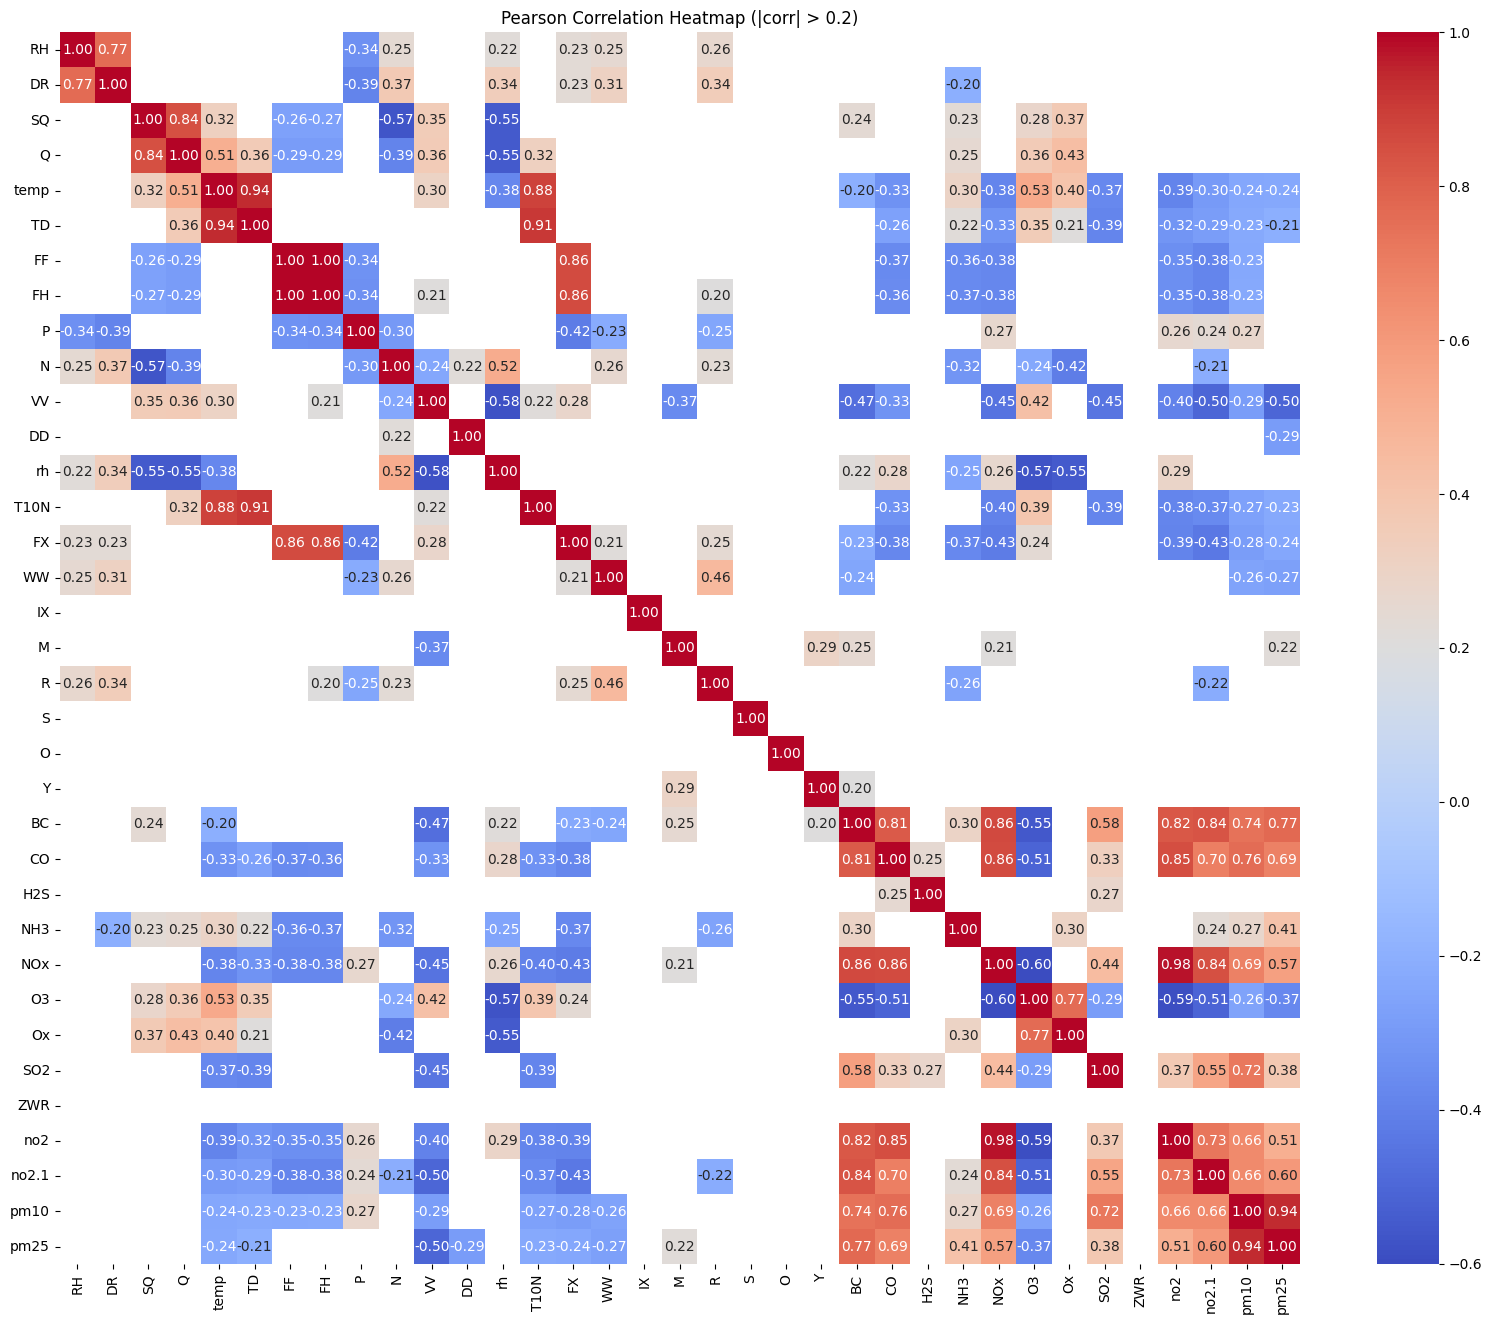

In [32]:
# Pearson correlation
columns = ['RH', 'DR', 'SQ', 'Q', 'temp', 'TD', 'FF', 'FH', 'P', 'N', 'VV',
       'DD', 'rh', 'T10N', 'FX', 'WW', 'IX', 'M', 'R', 'S', 'O', 'Y','BC', 'CO', 'H2S', 'NH3', 'NOx', 'O3', 'Ox', 'SO2',
       'ZWR', 'no2', 'no2.1', 'pm10', 'pm25']
corr = data[columns].corr()

# Mask weak correlations
mask = (abs(corr) < 0.2)
corr_masked = corr.mask(mask)

plt.figure(figsize=(20,16))
sns.heatmap(corr_masked, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Pearson Correlation Heatmap (|corr| > 0.2)")
plt.show()


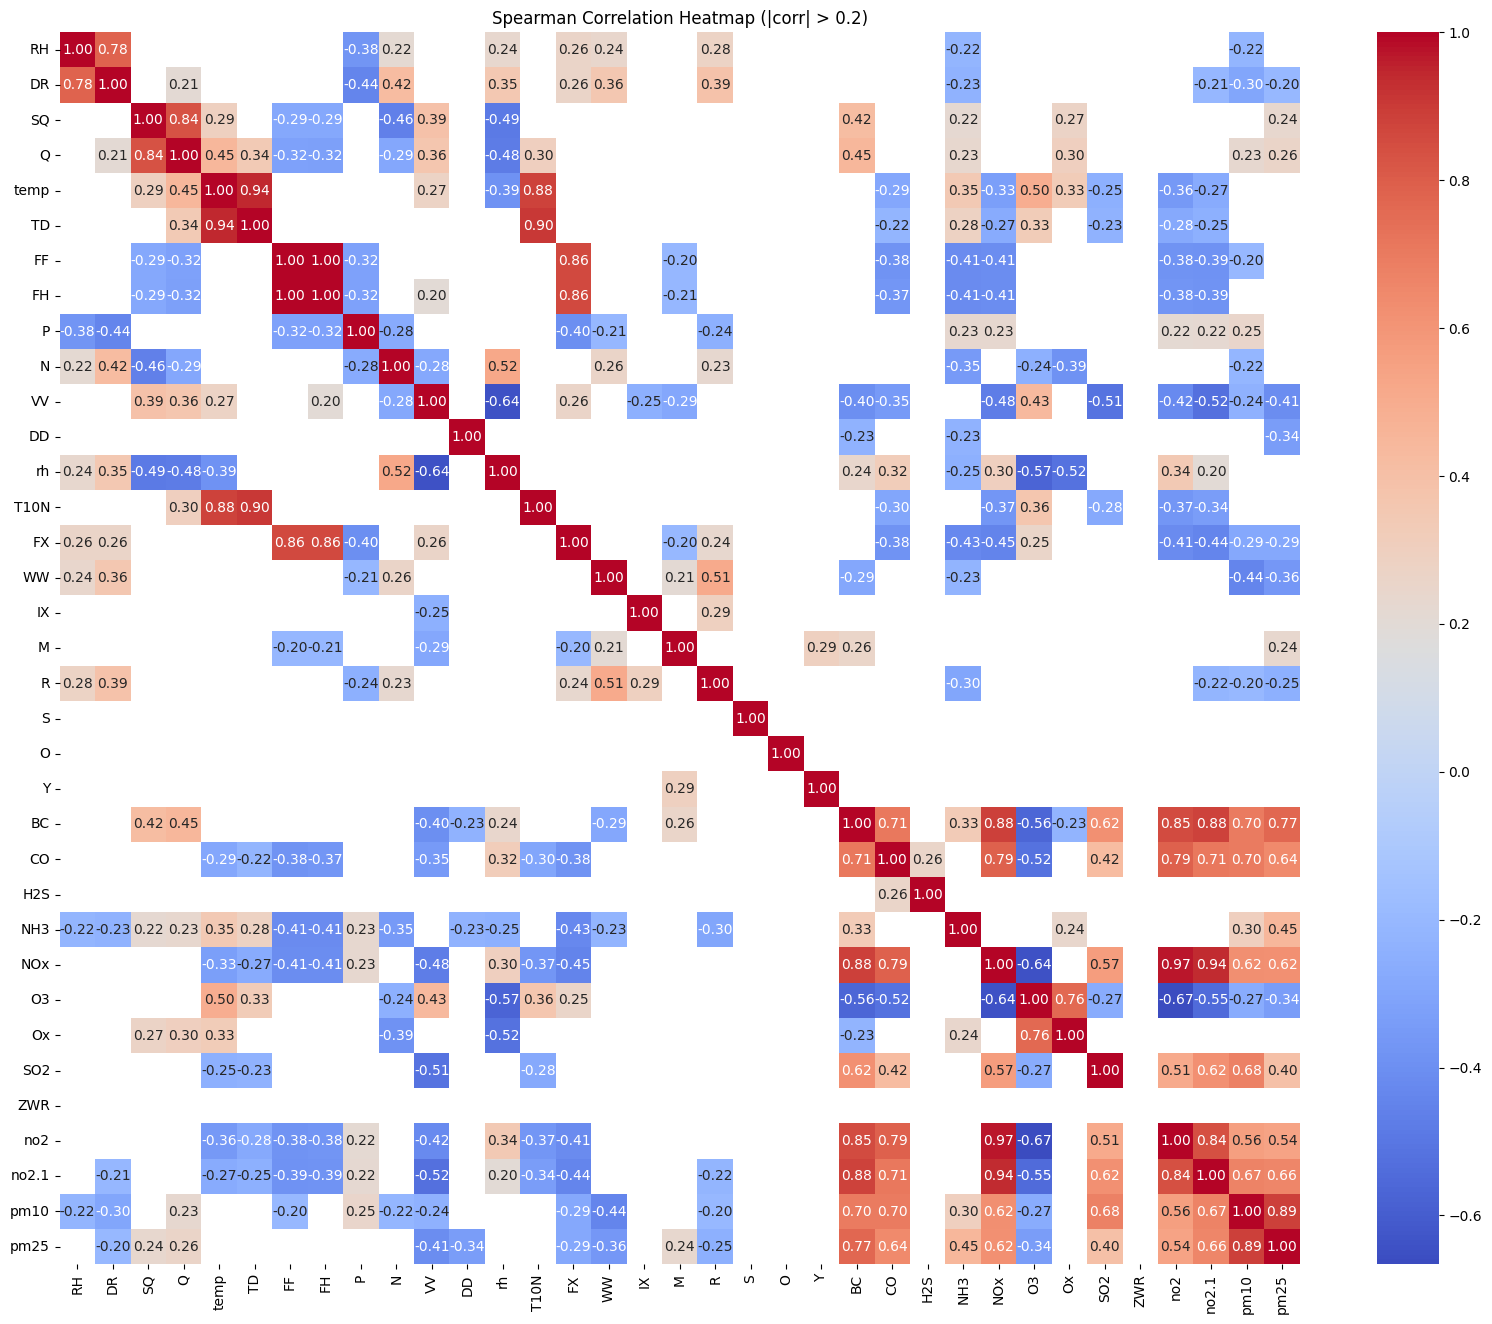

In [33]:
corr = data[columns].corr(method='spearman')

# Mask weak correlations
mask = (abs(corr) < 0.2)
corr_masked = corr.mask(mask)

plt.figure(figsize=(20,16))
sns.heatmap(corr_masked, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Spearman Correlation Heatmap (|corr| > 0.2)")
plt.show()

### Analysis 5: Precipitation categories vs highly correlated variables

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


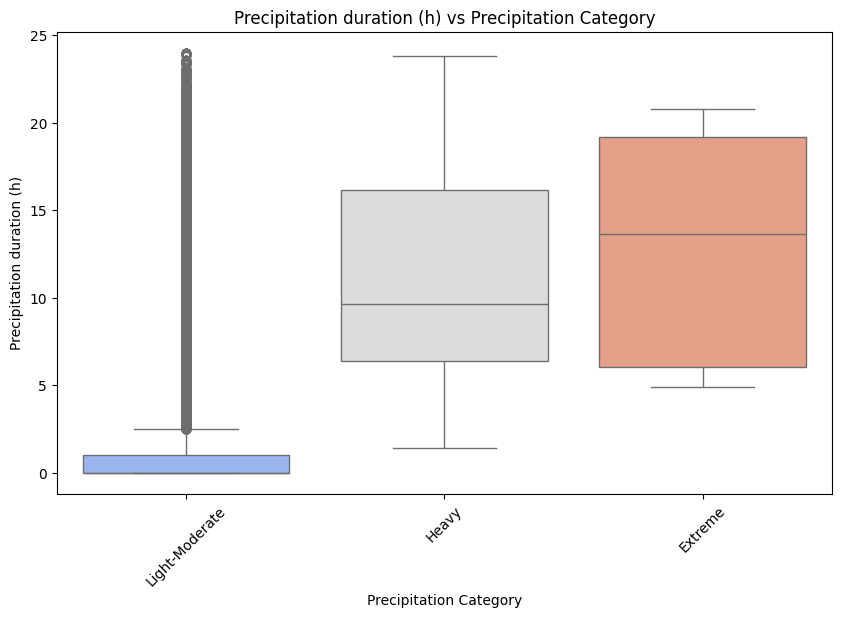

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


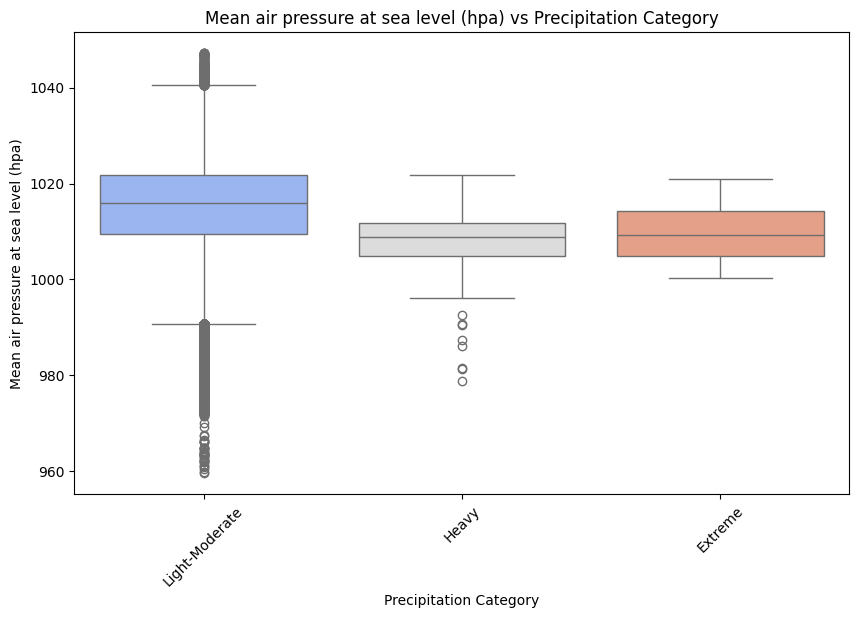

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


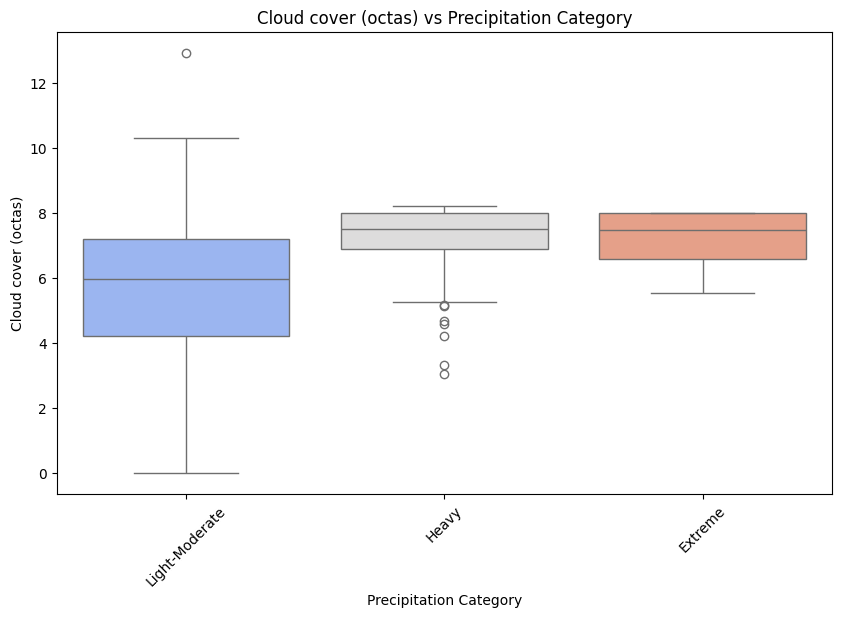

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


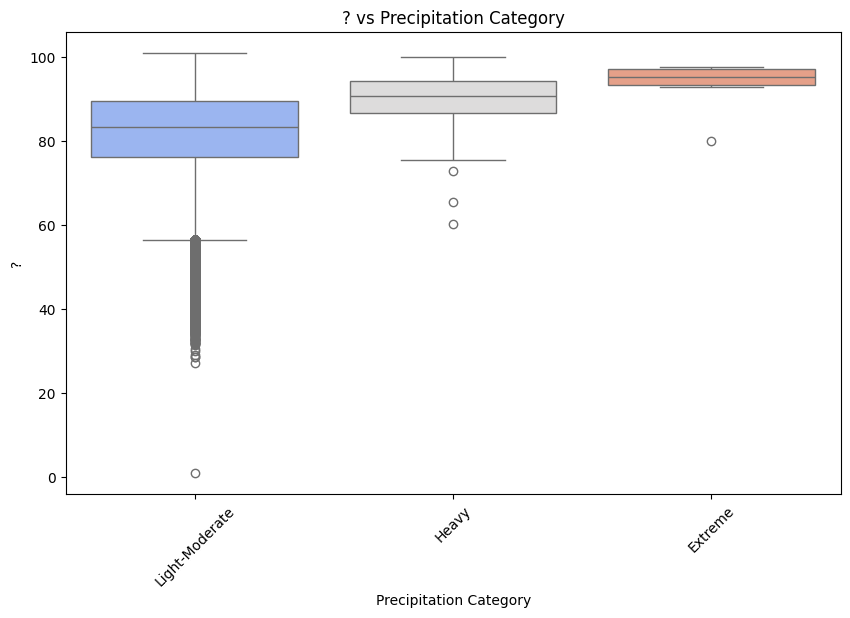

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


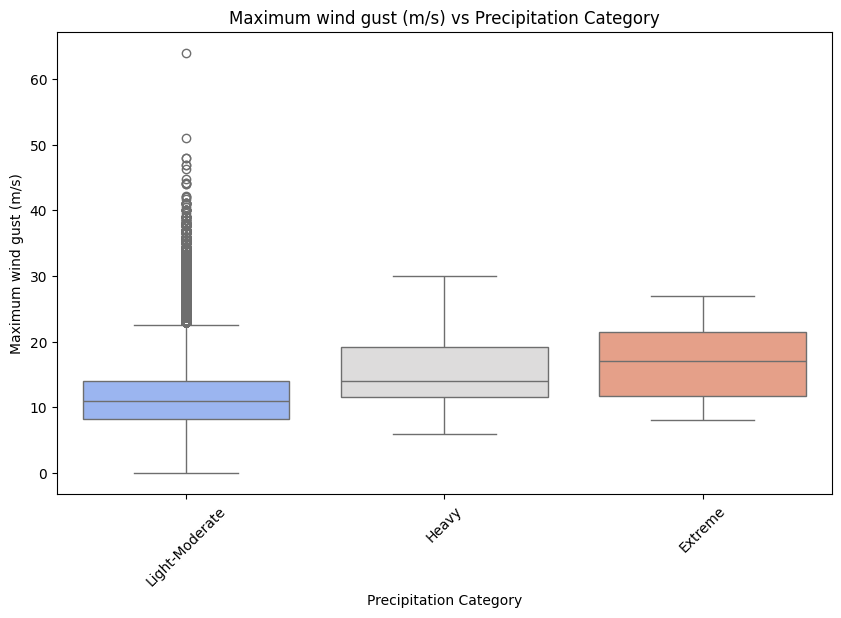

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


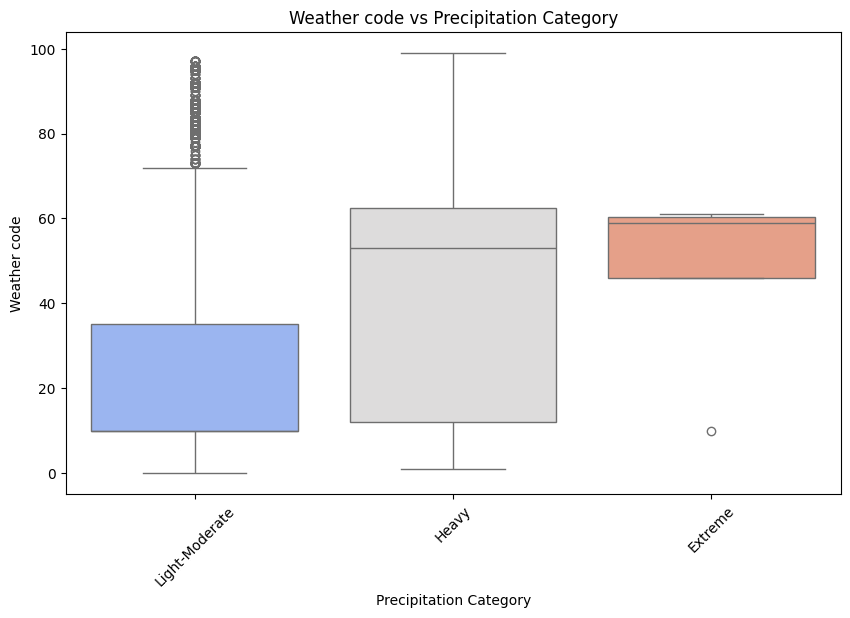

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


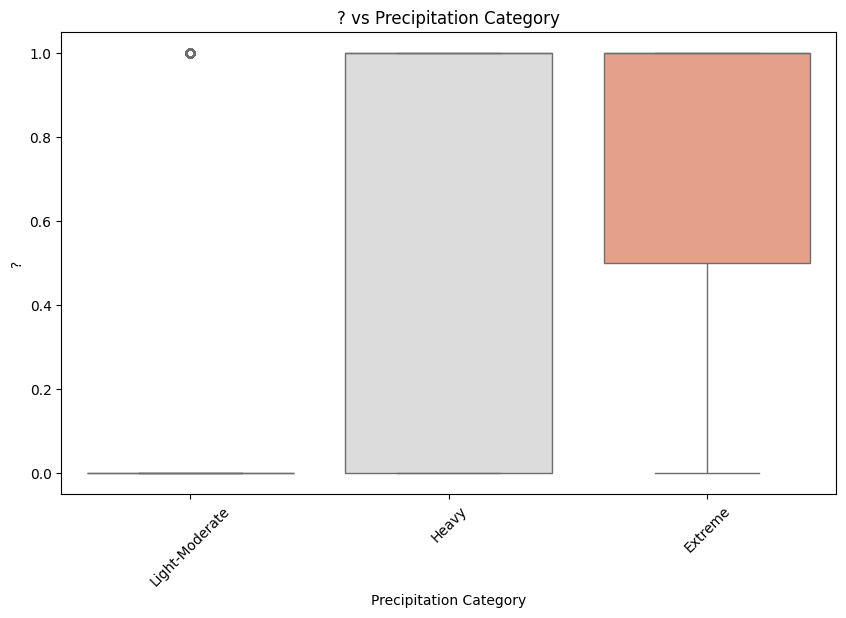

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


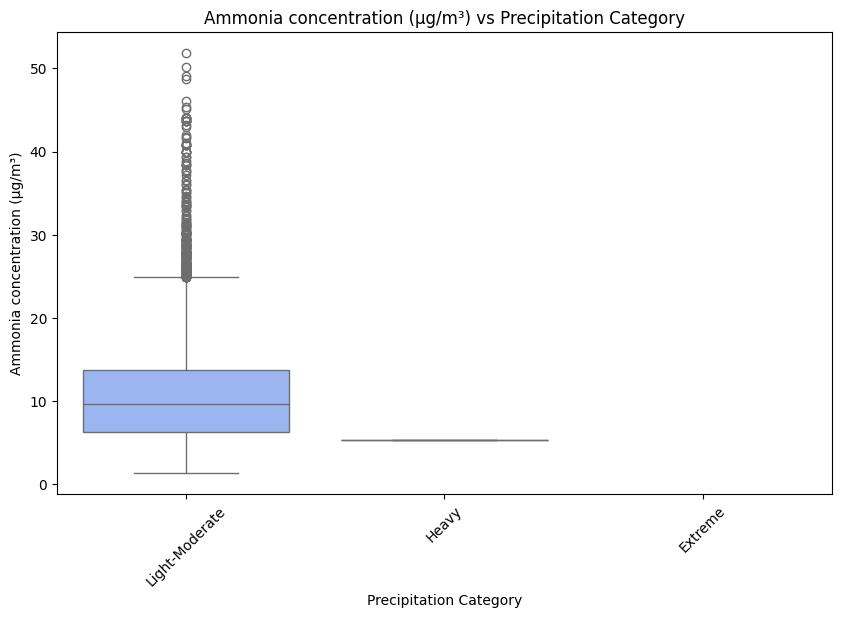

C:\Users\majak\AppData\Local\Temp\ipykernel_27356\4219453855.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')


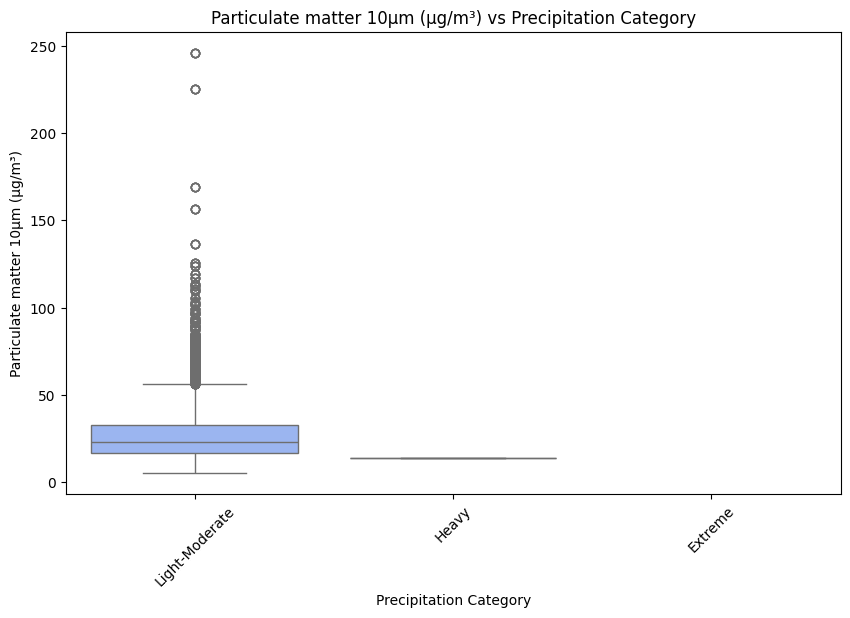

In [35]:
numerical_variables = ["DR", "P", "N", "rh", "FX", "WW", "R", "NH3", "pm10"]
names = {
    "DR": "Precipitation duration (h)",
    "P": "Mean air pressure at sea level (hpa)",
    "N": "Cloud cover (octas)",
    "rh": "?",
    "FX": "Maximum wind gust (m/s)",
    "WW": "Weather code",
    "R": "?",
    "NH3": "Ammonia concentration (µg/m³)",
    "pm10": "Particulate matter 10µm (µg/m³)"
}

for col in numerical_variables:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='precipitation_category', y=col, data=data, palette='coolwarm')
    plt.title(f'{names[col]} vs Precipitation Category')
    plt.xlabel('Precipitation Category')
    plt.ylabel(names[col])
    plt.xticks(rotation=45)
    plt.show()

### Analysis 6: Timeseries exploration

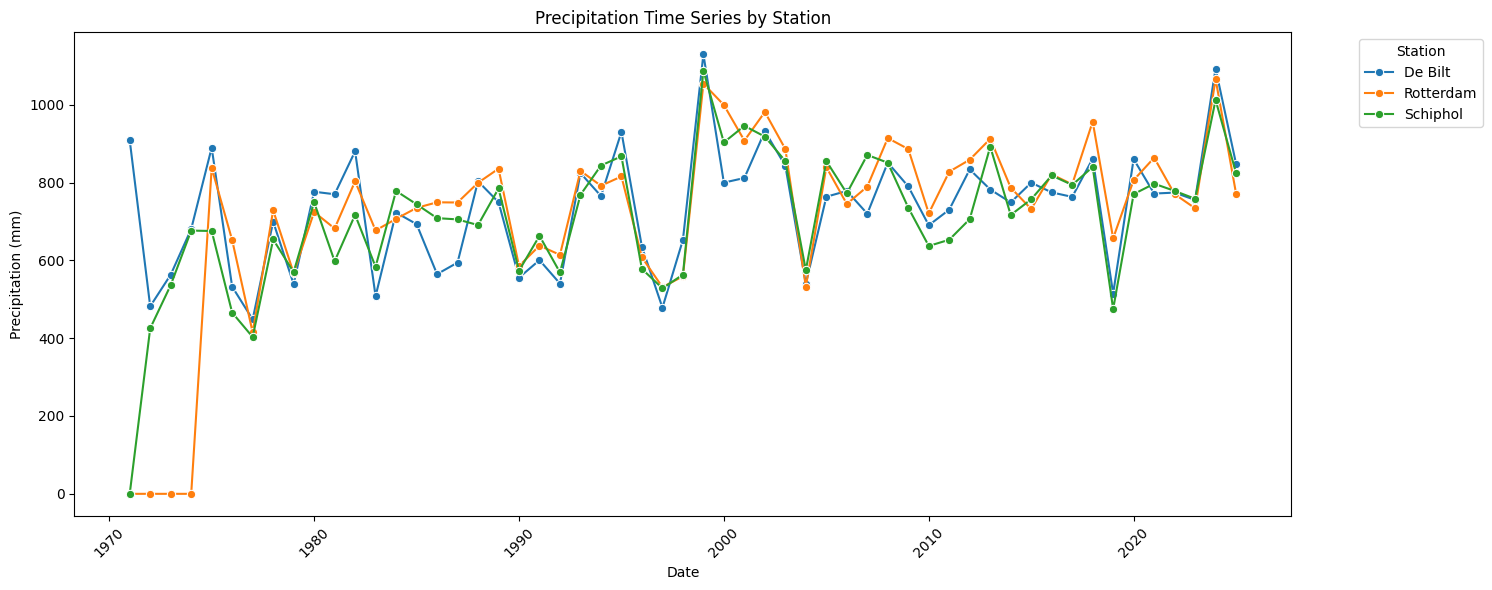

In [43]:
top_stations = data.groupby('KNMI_station')['RH'].sum().nlargest(3).index
df_plot = data[data['KNMI_station'].isin(top_stations)]
df_monthly = df_plot.groupby(['KNMI_station', pd.Grouper(key='time', freq='YE')])['RH'].sum().reset_index()

# Precipitation by station
plt.figure(figsize=(15,6))

# Plot each station as a separate line
sns.lineplot(data=df_monthly, x='time', y='RH', hue='KNMI_station', marker='o')

plt.title('Precipitation Time Series by Station')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=45)
plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()